In [1]:
import os
from tqdm import tqdm
import pandas as pd

from image_utils import *
from preprocessing import *

In [2]:
img_dir = os.path.join("iapr-26-uno-vision-challenge", "train_images")
annotations_file = os.path.join("iapr-26-uno-vision-challenge", "train") + '.csv'
annotations = pd.read_csv(annotations_file)

## Separate the cases
There are two cases, one with a white background (black box indicator) and another with a colorful background (yellow box indicator).

First we threshold the image on the color of the indicator (gives us a binary image, true if color is close to the indicator color). \
Then we use morphological dilation and erosion to only keep the large disks filled with indicator color (the indicators have a large disc filled with their color, whereas the cards have patterns that break continuity, so the cards are removed by the erosion).

Finally we check which quadrant has the most signal (as the indicator in to the right of the player) to determine the player. 

Functions to determine the player (in preprocessing.py):
- determine_case(img, thresh=200)
- find_player(im_obj)
- detection_case_0(img, display=False)
- detection_case_1(img, display=False)
- detection_player(img, display=False)

iapr-26-uno-vision-challenge\train_images\L1000981.jpg


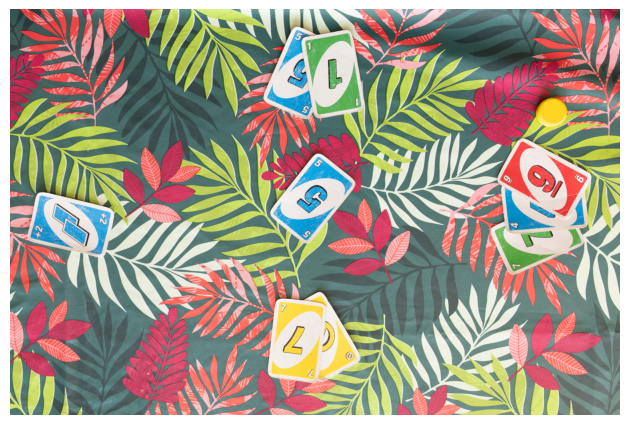

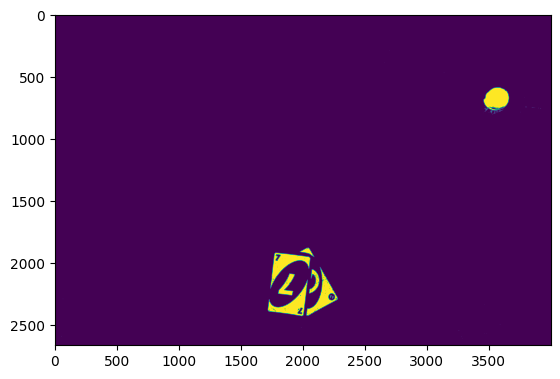

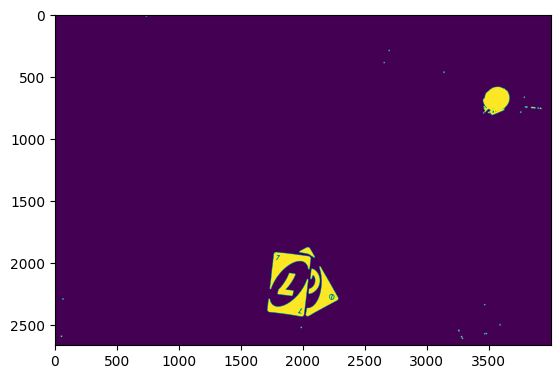

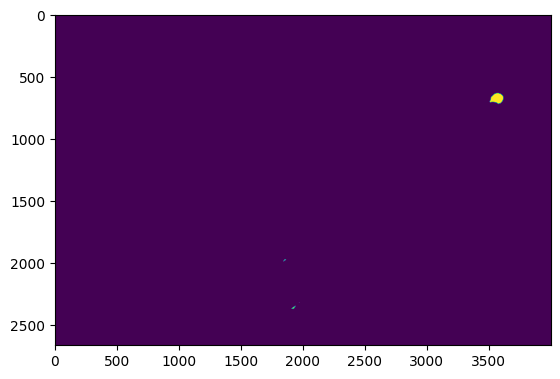

1
p2


In [3]:
image_path = get_random_imagepath(img_dir)
# L1000967, L1000974
#image_path = os.path.join(img_dir, "L1000967") + '.jpg'
img = load_image(image_path)
player = detection_player(img, display=True)

In [4]:
# Test for all train images

all_correct = True
image_id_list = list(annotations['image_id'])
active_player_list = list(annotations['active_player'])
for image_id, active_player in tqdm(zip(image_id_list, active_player_list), total=len(image_id_list)):
    image_path = os.path.join(img_dir, image_id) + '.jpg'
    img = load_image(image_path, display=False)
    player = detection_player(img, display=False)
    all_correct = all_correct and (player == active_player)
    if (player != active_player):
        print(image_id)
print(f"All detection correct = {all_correct}")

 80%|█████████████████████████████████████████████████████████████████▊                | 65/81 [06:23<02:19,  8.72s/it]

L1000967


 89%|████████████████████████████████████████████████████████████████████████▉         | 72/81 [07:24<01:18,  8.73s/it]

L1000974


100%|██████████████████████████████████████████████████████████████████████████████████| 81/81 [08:42<00:00,  6.45s/it]

All detection correct = False


### Threshold test

iapr-26-uno-vision-challenge/train_images/L1000979.jpg


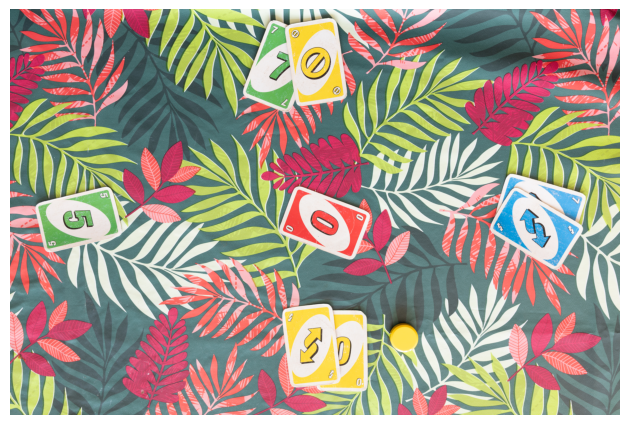

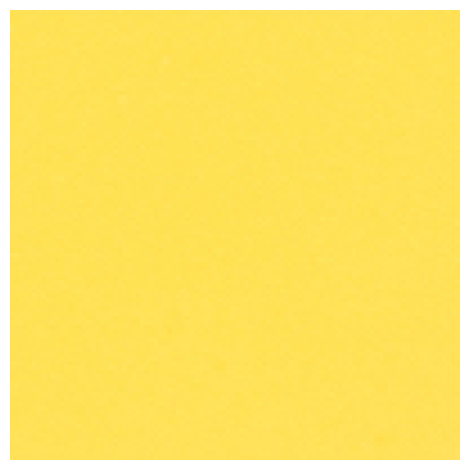

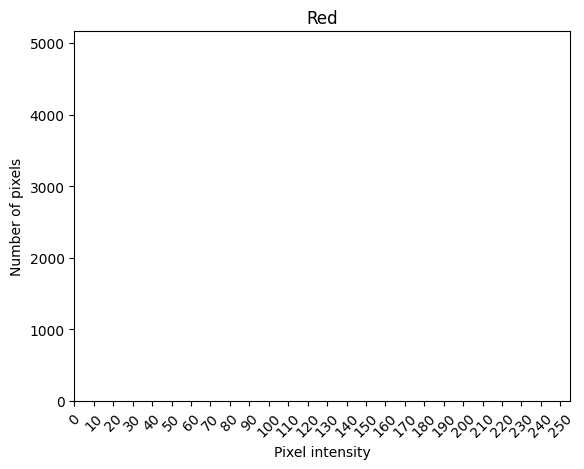

254.3544


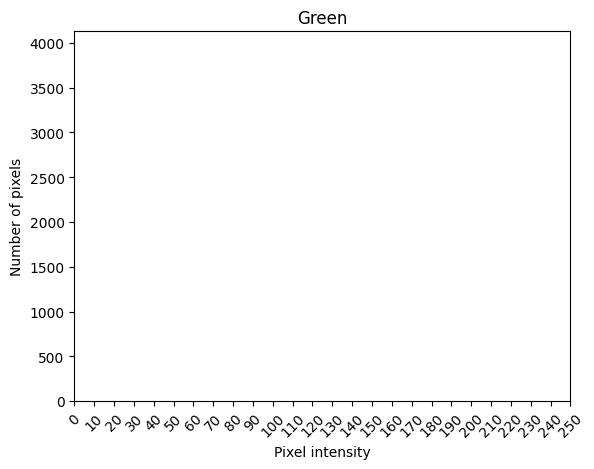

225.5376


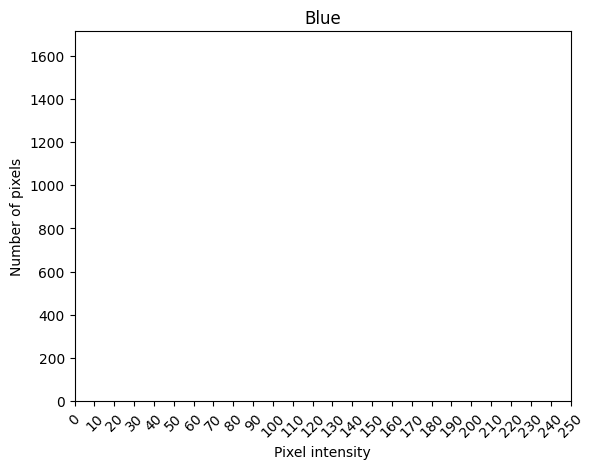

86.2226


In [5]:
#image_path = "iapr-26-uno-vision-challenge/train_images/L1000837.jpg"
#img = load_image(image_path)
#img = img[2400:2550, 2200:2300, :]

#image_path = "iapr-26-uno-vision-challenge/train_images/L1000775.jpg"
#img = load_image(image_path)
#img = img[2150:2280, 370:600, :]

#image_path = "iapr-26-uno-vision-challenge/train_images/L1000784.jpg"
#img = load_image(image_path)
#img = img[520:620, 3500:3600, :]

#image_path = "iapr-26-uno-vision-challenge/train_images/L1000977.jpg"
#img = load_image(image_path)
#img = img[2250:2300, 2250:2400, :]

#image_path = "iapr-26-uno-vision-challenge/train_images/L1000964.jpg"
#img = load_image(image_path)
#img = img[300:350, 1600:1650, :]

image_path = "iapr-26-uno-vision-challenge/train_images/L1000979.jpg"
img = load_image(image_path)
img = img[2110:2210, 2540:2640, :]

display_rgb_hist(img)